In [1]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
from tqdm import tqdm
from torch.utils.data import DataLoader
from jiwer import cer

In [2]:
# !wget "https://www.openslr.org/resources/103/Odia_train.tar.gz"

In [3]:
# !tar -xvzf Odia_test.tar.gz

In [4]:
# !wget "https://www.openslr.org/resources/103/Odia_test.tar.gz"

In [3]:
# Load model directly
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
from transformers import WhisperTokenizer
from transformers import WhisperFeatureExtractor
from transformers import WhisperForConditionalGeneration




processor = AutoProcessor.from_pretrained("Ranjit/odia_whisper_small_v3.0")
model = AutoModelForSpeechSeq2Seq.from_pretrained("Ranjit/odia_whisper_small_v3.0").to('cuda')

In [4]:
import torch
print(torch.cuda.is_available())  # Should print: True


True


In [5]:
tokenizer = WhisperTokenizer.from_pretrained("Ranjit/odia_whisper_small_v3.0",language='bengali',task='transcribe')
feature_extractor = WhisperFeatureExtractor.from_pretrained("Ranjit/odia_whisper_small_v3.0",language='bengali',task='transcribe')

In [19]:
import os
from datasets import Dataset, Audio

# Use absolute paths
transcript_path = r"/home/intern/subham/train/transcription.txt"
audio_dir = r"/home/intern/subham/train/audio"

# Read file
data = []
validation=[]


with open(transcript_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue

        if " " not in line:
            print(f"⚠️ Line {i} has no space: {line}")
            continue

        audio_id, text = line.split(" ", 1)  # split on the FIRST space only
        audio_file = f"{audio_id}.wav"
        audio_path = os.path.join(audio_dir, audio_file)

        if not os.path.exists(audio_path):
            print(f"❌ Audio file missing: {audio_path}")
            continue

        data.append({"audio": audio_path, "text": text})





# Convert to dataset
dataset = Dataset.from_list(data).cast_column("audio", Audio(sampling_rate=16000))

print(dataset[0])


{'audio': {'path': '/home/intern/subham/train/audio/281474976712572.wav', 'array': array([ 4.19095159e-09, -1.16415322e-09,  1.62981451e-09, ...,
       -7.73333013e-04, -4.28574131e-04, -6.98484655e-05]), 'sampling_rate': 16000}, 'text': 'ମୋର ଡାହାଣ ପାଖ ବହୁତ ଦୁର୍ବଳ ମନେ ହେଉଛି ଡାହାଣ ହାତଟା ସମ୍ପୂର୍ଣ  ଉପରକୁ ଟେକି ହେଉନାହିଁ'}


In [20]:
print(dataset[10]['audio'])


{'path': '/home/intern/subham/train/audio/281474976714148.wav', 'array': array([ 2.06637196e-09, -6.92671165e-09, -3.21597327e-09, ...,
       -1.89680984e-04, -6.38096099e-05,  2.55622763e-06]), 'sampling_rate': 16000}


In [21]:
import evaluate
import re


def normalize_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove only ", ', and ,
    text = re.sub(r'[",\']', '', text)
    # Optional: remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [22]:
import torch
model.eval()
model.config.use_cache=True

for idx in range(5):

    target = normalize_text(dataset[idx]['text'])
    audio_original = dataset[idx]['audio']['array']
    original_sample_rate = dataset[idx]['audio']['sampling_rate']

    # audio_16000 = down_sample_audio(audio_original, original_sample_rate)

    input_feature = feature_extractor(raw_speech=audio_original,
                                    sampling_rate=16000,
                                    return_tensors='pt').input_features

    with torch.no_grad():
        op = model.generate(input_feature.to('cuda'), language='bengali', task='transcribe')


    text_pred =  tokenizer.batch_decode(op,skip_special_tokens=True )[0]

    print(f'-------{idx}------')
    print(f'true : {target} \npred : {text_pred}')
    print('\n ')

-------0------
true : ମୋର ଡାହାଣ ପାଖ ବହୁତ ଦୁର୍ବଳ ମନେ ହେଉଛି ଡାହାଣ ହାତଟା ସମ୍ପୂର୍ଣ ଉପରକୁ ଟେକି ହେଉନାହିଁ 
pred : ମୋର ଡାହାଣ ପାଖ ବହୁତ ଦୁର୍ବଳ ମନେ ହେଉଛି ଡାହାଣ ହାତଟା ସମ୍ପୂର୍ଣ  ଉପରକୁ ଟେକି ହେଉନାହିଁ

 
-------1------
true : ଦେହ ସାରା କୁଣ୍ଡାଇ କୁଣ୍ଡାଇ ଫଳି ଯାଉଛି 
pred : ଦେହ  ସାରା  କୁଣ୍ଡାଇ କୁଣ୍ଡାଇ ଫଳି  ଯାଉଛି

 
-------2------
true : ସାର ମୋର ବିଜୁ କୃଷକ କାର୍ଡ ପାଇଁ କଣ କାଗଜ ପତ୍ର ଦରକାର 
pred : ସାର ମୋର ବିଜୁ କୃଷକ କାର୍ଡ ପାଇଁ କଣ କାଗଜ ପତ୍ର ଦରକାର

 
-------3------
true : ସାର ମୋର ସାତ ମାସର ଗର୍ଭ ଗୋଡ଼ ହାତ ମୁହଁ ଫୁଲି ଯାଉଛି 
pred : ସାର ମୋର ସାତ ମାସର ଗର୍ଭ ଗୋଡ଼ ହାତ ମୁହଁ ଫୁଲି ଯାଉଛି

 
-------4------
true : ସାର ମୋର ପିରିଅଡ଼ ରେ ଭଲରେ ବ୍ଲିଡ଼ିଙ୍ଗ ହଉନାହିଁ ଅଳ୍ପ ହୋଇ ବନ୍ଦ ହୋଇଯାଉଛି 
pred : ସାର ମୋର ପିରିଅଡ଼ ରେ ଭଲରେ ବ୍ଲିଡ଼ିଙ୍ଗ ହଉନାହିଁ ଅଳ୍ପ ହୋଇ ବନ୍ଦ ହୋଇଯାଉଛି

 


In [11]:
class whisper_training_dataset(torch.utils.data.Dataset):
    def __init__(self, dataset, max_len):#daatset is huggingface dataset object
        self.dataset = dataset
        self.max_len = max_len
        self.bos_token = model.config.decoder_start_token_id

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        audio_data = (item['audio']["array"])
        input_features = feature_extractor(audio_data, sampling_rate=16000,return_tensors='pt').input_features[0]

        # Process the transcription
        transcription = item['text']

        # Create labels
        labels = tokenizer(transcription, padding="max_length", max_length=self.max_len, truncation=True, return_tensors="pt")
        labels = labels["input_ids"].masked_fill(labels['attention_mask'].ne(1), -100)
        labels = labels[0][1:]


        return {
            "input_features": input_features,
            "labels": labels
        }

In [ ]:
dataset = whisper_training_dataset(dataset=dataset, max_len=400)

train_dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,  # Adjust batch size as needed
    shuffle=True,  # Shuffle data during training
)

In [13]:
import os
from datasets import Dataset, Audio

# Use absolute paths
transcript_path = r"/home/intern/subham/test/transcription.txt"
audio_dir = r"/home/intern/subham/test/audio"

# Read file

validation=[]


with open(transcript_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue

        if " " not in line:
            print(f"⚠️ Line {i} has no space: {line}")
            continue

        audio_id, text = line.split(" ", 1)  # split on the FIRST space only
        audio_file = f"{audio_id}.wav"
        audio_path = os.path.join(audio_dir, audio_file)

        if not os.path.exists(audio_path):
            print(f"❌ Audio file missing: {audio_path}")
            continue

        validation.append({"audio": audio_path, "text": text})





# Convert to dataset
validation_dataset = Dataset.from_list(validation).cast_column("audio", Audio(sampling_rate=16000))

print(validation_dataset[0])


{'audio': {'path': '/home/intern/subham/test/audio/281474976714150.wav', 'array': array([ 2.76486389e-09, -8.44011083e-10, -1.04773790e-09, ...,
        2.72560865e-05,  5.52320853e-05,  4.53973189e-05]), 'sampling_rate': 16000}, 'text': 'ସାର ତିନି ମାସ ହେଲା ମୋର ହେଲ୍ଥ କାର୍ଡ ବନ୍ଦହେଇଯାଇଛି ମୁ ଏଇ କାର୍ଡ ରେ ଔଷଧ ପାଇପାରିବି'}


In [14]:
def evaluation(model):
    device = 'cuda'

    test_dataset = whisper_training_dataset(dataset=validation_dataset, max_len=60)

    test_dataloader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=True,
    )

    model.eval()
    predictions = []
    references = []

    progress_bar = tqdm(test_dataloader, total=len(test_dataloader))

    for batch in progress_bar:
        model.eval()
        model.config.use_cache = True

        input_features = batch["input_features"].to(device)
        labels = batch["labels"].to(device)

        with torch.no_grad():
            generated_tokens = model.generate(input_features=input_features, language='bengali', task='transcribe')

        decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        # Update global lists
        predictions.extend(decoded_preds)
        references.extend(decoded_labels)

        # Compute batch WER (not cumulative)
        batch_cer = cer(decoded_labels, decoded_preds) * 100
        progress_bar.set_postfix(batch_CER=f"{batch_cer:.2f}%")

    total_cer = cer(references,predictions) * 100
    return total_cer

In [16]:
torch.cuda.empty_cache()
evaluation(model)

100%|██████████| 55/55 [14:48<00:00, 16.15s/it, batch_CER=141.18%]


142.0880364214326

In [15]:
from peft import LoraConfig, PeftModel, LoraModel, LoraConfig, get_peft_model

config = LoraConfig(r=64, lora_alpha=64, target_modules=["q_proj", "v_proj", "q_proj", "out_proj"], lora_dropout=0.05, bias="none")

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 10,616,832 || all params: 252,351,744 || trainable%: 4.2072


In [40]:
# model.save_pretrained('lora_model')

# model = PeftModel.from_pretrained(model,model_id='lora_model')

# for n,p in model.named_parameters():
#     print(n,p.requires_grad)


In [16]:

test_dataset = whisper_training_dataset(dataset=validation_dataset, max_len=400)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,  # Adjust batch size as needed
    shuffle=True,  # Shuffle data during training
)

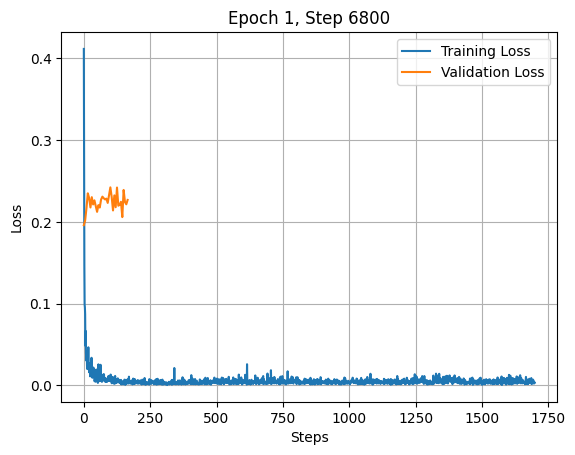

KeyboardInterrupt: 

In [17]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

torch.cuda.empty_cache()
model.config.use_cache = False
model.train()

device = 'cuda'
# Filter parameters with requires_grad=True
requires_grad_params = filter(lambda x: x[1].requires_grad, model.parameters())
optimizer = torch.optim.AdamW(requires_grad_params, lr=5e-4)  # Only for LoRA Training

max_epochs = 4
gradient_accumulation_steps = 4

running_train_loss = []
running_val_loss = []
running_cer = []

global_step = 0
accumulated_loss = 0

for epoch in range(max_epochs):
    for step, batch in enumerate(tqdm(train_dataloader, total=len(train_dataloader), leave=False)):

        model.config.use_cache = False
        model.train()
        input_features, labels = batch["input_features"].to(device), batch["labels"].to(device)

        outputs = model(input_features, labels=labels)
        loss = outputs.loss
        loss = loss / gradient_accumulation_steps  # Scale the loss

        loss.backward()
        accumulated_loss += loss.item()

        if (step + 1) % gradient_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
            running_train_loss.append(accumulated_loss)
            accumulated_loss = 0
            global_step += 1

            # Validation loop
            if global_step % 50 == 0:
                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for val_batch in test_dataloader:
                        val_input, val_labels = val_batch["input_features"]